IMPORTING LIBRARIES

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

ANN MODELLING

In [5]:
data = pd.read_excel('Airfoil - Lift vs Drag.xlsx')

print("Dataset shape:", data.shape)
data.head(10)

Dataset shape: (2499, 71)


,airfoilName,upperSurfaceCoeff1,upperSurfaceCoeff2,upperSurfaceCoeff3,upperSurfaceCoeff4,upperSurfaceCoeff5,upperSurfaceCoeff6,upperSurfaceCoeff7,upperSurfaceCoeff8,upperSurfaceCoeff9,...,lowerSurfaceCoeff30,lowerSurfaceCoeff31,reynoldsNumber,alpha,coefficientLift,coefficientDrag,coefficientParasiteDrag,coefficientMoment,topXTR,botXTR
0,2032c,103000000,-74000000,-105000000,-51200000,29400000,88500000,96800000,50300000,-28100000,...,0.115,-0.00689,50000,-8.25,-0.2446,0.11407,0.10788,-0.0201,1.0,0.0956
1,2032c,103000000,-74000000,-105000000,-51200000,29400000,88500000,96800000,50300000,-28100000,...,0.115,-0.00689,50000,-8.00,-0.2475,0.11417,0.10812,-0.0218,1.0,0.0969
2,2032c,103000000,-74000000,-105000000,-51200000,29400000,88500000,96800000,50300000,-28100000,...,0.115,-0.00689,50000,-7.75,-0.2530,0.11491,0.10902,-0.0240,1.0,0.0975
3,2032c,103000000,-74000000,-105000000,-51200000,29400000,88500000,96800000,50300000,-28100000,...,0.115,-0.00689,50000,-7.50,-0.2326,0.10640,0.10052,-0.0214,1.0,0.1007
4,2032c,103000000,-74000000,-105000000,-51200000,29400000,88500000,96800000,50300000,-28100000,...,0.115,-0.00689,50000,-7.25,-0.2270,0.10345,0.09765,-0.0208,1.0,0.1042
5,2032c,103000000,-74000000,-105000000,-51200000,29400000,88500000,96800000,50300000,-28100000,...,0.115,-0.00689,50000,-7.00,-0.2270,0.10172,0.09604,-0.0205,1.0,0.1074
6,2032c,103000000,-74000000,-105000000,-51200000,29400000,88500000,96800000,50300000,-28100000,...,0.115,-0.00689,50000,-6.75,-0.2298,0.10096,0.09544,-0.0212,1.0,0.1103
7,2032c,103000000,-74000000,-105000000,-51200000,29400000,88500000,96800000,50300000,-28100000,...,0.115,-0.00689,50000,-6.50,-0.2352,0.10161,0.09625,-0.0237,1.0,0.1117
8,2032c,103000000,-74000000,-105000000,-51200000,29400000,88500000,96800000,50300000,-28100000,...,0.115,-0.00689,50000,-6.25,-0.2376,0.10049,0.09527,-0.0248,1.0,0.1126
9,2032c,103000000,-74000000,-105000000,-51200000,29400000,88500000,96800000,50300000,-28100000,...,0.115,-0.00689,50000,-6.00,-0.2347,0.09499,0.08985,-0.0189,1.0,0.1159


In [39]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

corr_matrix = numeric_data.corr()

# Correlation with Lift
corr_lift = corr_matrix['coefficientLift'].abs().sort_values(ascending=False)

# Correlation with Drag
corr_drag = corr_matrix['coefficientDrag'].abs().sort_values(ascending=False)

print("Top correlated with Lift:\n", corr_lift.head(10))
print("\nTop correlated with Drag:\n", corr_drag.head(10))

Top correlated with Lift:
 coefficientLift        1.000000
alpha                  0.938063
topXTR                 0.881757
botXTR                 0.804410
coefficientMoment      0.381608
upperSurfaceCoeff12    0.290322
upperSurfaceCoeff18    0.288476
upperSurfaceCoeff7     0.277628
upperSurfaceCoeff5     0.273732
upperSurfaceCoeff4     0.271718
Name: coefficientLift, dtype: float64

Top correlated with Drag:
 coefficientDrag            1.000000
coefficientParasiteDrag    0.997507
coefficientMoment          0.325231
reynoldsNumber             0.238210
botXTR                     0.165081
lowerSurfaceCoeff25        0.164440
lowerSurfaceCoeff26        0.161143
lowerSurfaceCoeff24        0.159753
upperSurfaceCoeff18        0.157361
lowerSurfaceCoeff1         0.156280
Name: coefficientDrag, dtype: float64


In [40]:
selected_inputs = ['alpha', 'topXTR', 'botXTR', 'reynoldsNumber']

X_df = data[selected_inputs]
Y_df = data[['coefficientLift', 'coefficientDrag']]

X = X_df.values
Y = Y_df.values

In [41]:
X

array([[-8.250e+00,  1.000e+00,  9.560e-02,  5.000e+04],
       [-8.000e+00,  1.000e+00,  9.690e-02,  5.000e+04],
       [-7.750e+00,  1.000e+00,  9.750e-02,  5.000e+04],
       ...,
       [-8.500e+00,  1.000e+00,  1.872e-01,  5.000e+04],
       [-8.250e+00,  1.000e+00,  1.952e-01,  5.000e+04],
       [-8.000e+00,  1.000e+00,  2.019e-01,  5.000e+04]], shape=(2499, 4))

In [42]:
Y

array([[-0.2446 ,  0.11407],
       [-0.2475 ,  0.11417],
       [-0.253  ,  0.11491],
       ...,
       [-0.5714 ,  0.11486],
       [-0.5585 ,  0.10997],
       [-0.5711 ,  0.1088 ]], shape=(2499, 2))

In [43]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(X)
Y_scaled = y_scaler.fit_transform(Y)

In [44]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X_scaled, Y_scaled, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 1749
Validation samples: 375
Test samples: 375


In [59]:
X_train.shape

(1749, 4)

In [66]:
n_inputs = X_train.shape[1]
n_train = X_train.shape[0]


model = Sequential([
    Dense(32, activation='relu', input_shape=(n_inputs,)),
    Dense(32, activation='relu'),
    Dense(2)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

c:\Users\Firdose Anjum\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=300,
    batch_size=32,
    verbose=1
)

Epoch 1/300


55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0667 - val_loss: 0.0199
Epoch 2/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0169 - val_loss: 0.0158
Epoch 3/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0146 - val_loss: 0.0141
Epoch 4/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0133 - val_loss: 0.0131
Epoch 5/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0123 - val_loss: 0.0120
Epoch 6/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0116 - val_loss: 0.0114
Epoch 7/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0108 - val_loss: 0.0105
Epoch 8/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - val_loss: 0.0100
Epoch 9/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0094
Epoch 10/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0091 - val_loss: 0.0090
Epoch 11/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0087 - val_loss: 0.0087
Epoch 12/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084 - val_lo

In [68]:
def evaluate(X_set, Y_set, name):
    Y_pred = model.predict(X_set)

    mse = mean_squared_error(Y_set, Y_pred)
    rmse = np.sqrt(mse)

    r2_lift = r2_score(Y_set[:,0], Y_pred[:,0])
    r2_drag = r2_score(Y_set[:,1], Y_pred[:,1])

    print(f"\n{name} Results:")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Lift :", r2_lift)
    print("R2 Drag :", r2_drag)

evaluate(X_train, Y_train, "Training")
evaluate(X_val, Y_val, "Validation")
evaluate(X_test, Y_test, "Test")

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Training Results:
MSE : 0.0045871594371552915
RMSE: 0.06772857179326382
R2 Lift : 0.9424568410111146
R2 Drag : 0.8370140945495599
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Validation Results:
MSE : 0.004558187437962694
RMSE: 0.06751434986699267
R2 Lift : 0.9379160626179504
R2 Drag : 0.8537766996440808
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Test Results:
MSE : 0.004656543752341506
RMSE: 0.06823887273645064
R2 Lift : 0.9319627919632165
R2 Drag : 0.8488873201100968


MULTI-OBJECTIVE OPTIMIZATION

In [69]:
class AirfoilProblem(Problem):

    def __init__(self):
        super().__init__(
            n_var=n_inputs,
            n_obj=2,
            xl=0.0,
            xu=1.0
        )

    def _evaluate(self, x, out, *args, **kwargs):
        y_pred = model.predict(x)

        lift = y_pred[:, 0]      # coefficientLift
        drag = y_pred[:, 1]      # coefficientDrag

        # pymoo minimizes → convert lift to negative
        out["F"] = np.column_stack([-lift, drag])

* NSGA-II = Non-dominated Sorting Genetic Algorithm II.
* It is a population-based evolutionary algorithm.

In [70]:
algorithm = NSGA2(pop_size=100)

res = minimize(
    AirfoilProblem(),
    algorithm,
    ('n_gen', 200),
    seed=1,
    verbose=True
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      7 |             - |             -
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
     2 |      200 |     13 |  0.0167556760 |         ideal
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
     3 |      300 |     14 |  0.1404763097 |         ideal
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
     4 |      400 |     17 |  0.0384530876 |         ideal
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
     5 |      500 |     25 |  0.0388866875 |         ideal
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
     6 |      600 |     34 |  0.0117004637 |         ideal
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
     7 |      700 |     32 |  0.0057338045 |         ideal
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
     8 |      800 |     34 |  0.0766008139 |         ideal
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
     9 |      900 |     39 |  0.0130470496 |         ideal
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
    10 |     1000 |     38 |  

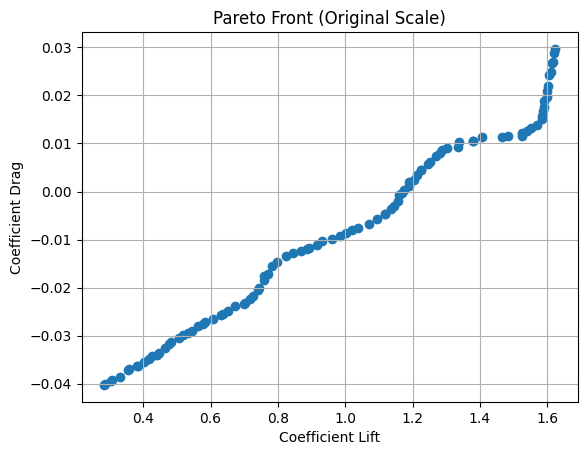

In [71]:
F = res.F

# Extract scaled objectives
lift_scaled = -F[:, 0]      # because we minimized -lift
drag_scaled = F[:, 1]       # drag minimized directly

# Convert back to original scale
Y_scaled_opt = np.column_stack([lift_scaled, drag_scaled])
Y_original_opt = y_scaler.inverse_transform(Y_scaled_opt)

lift_opt = Y_original_opt[:, 0]
drag_opt = Y_original_opt[:, 1]

plt.figure()
plt.scatter(lift_opt, drag_opt)
plt.xlabel("Coefficient Lift")
plt.ylabel("Coefficient Drag")
plt.title("Pareto Front (Original Scale)")
plt.grid()
plt.show()

In [80]:
X_opt = res.X

In [81]:
X_opt

array([[0.60641599, 0.99994836, 0.15833472, 0.81218609],
       [0.76827781, 0.41581398, 0.99999854, 0.77367173],
       [0.66472605, 0.59470252, 0.99993537, 0.99655517],
       [0.61212928, 0.9999992 , 0.19029631, 0.80282101],
       [0.61988948, 0.95961605, 0.99999475, 0.49996546],
       [0.65679803, 0.99494113, 0.41552315, 0.73211315],
       [0.69128578, 0.99491134, 0.54230652, 0.76921399],
       [0.65241215, 0.99993594, 0.37926121, 0.74468291],
       [0.69186918, 0.98528833, 0.51808663, 0.77667865],
       [0.60288865, 0.93088057, 0.9999993 , 0.51267679],
       [0.6310666 , 0.90332591, 0.99999991, 0.48679403],
       [0.64326212, 0.99945902, 0.2851275 , 0.78453811],
       [0.74202512, 0.43136364, 0.99997772, 0.84763738],
       [0.65617073, 0.89941345, 0.99999984, 0.48843838],
       [0.71285832, 0.4276413 , 0.99993537, 0.926895  ],
       [0.66006656, 0.65795563, 0.9949634 , 0.97426242],
       [0.65241876, 0.99956234, 0.4095011 , 0.74106122],
       [0.68279105, 0.53811953,